# Exploratory Data Analysis — `dataset/dataset.csv`

This notebook is a **fully independent** EDA pass over the cleaned, aggregated transaction
log produced by `notebook/merge_and_aggregate.ipynb` (`merge_dataset.py` + `aggregate_dataset.py`
&rarr; `dataset/dataset.csv`). It does not modify, replace, or depend on
`notebook/data-processing.ipynb` — some duplication of basic checks (missing values, unique
counts, etc.) between the two notebooks is expected and accepted.

## Business context

The goal is demand forecasting for every item at every outlet, horizon &le; 4 days. The central
SCM team currently ships to **Region 1** outlets every **Monday & Thursday**, and to **Region 2**
outlets every **Tuesday & Friday** — so the eventual model needs to predict *cumulative* demand
over the lead-time window until the next shipment (a 3-day or 4-day window, depending on region
and shipment day).

**Important constraint:** as of this notebook, there is no Region 1 / Region 2 (or any
delivery-schedule) mapping anywhere in the data (`dataset/outlets.csv` only has
`Kecamatan`/`Kota`). This notebook does **not** guess at or invent that mapping — the
day-of-week and lead-time-window analyses below are deliberately generic/non-region-segmented
proxies. The gap itself is called out explicitly in the final "Open Questions / Data Gaps"
section.

## Executive Summary

- **Shape & quality**: 693,563 rows x 7 columns, 2024-01-01 to 2025-12-31, zero missing values, zero exact or business-key duplicates. 12 categories, 109 SKUs, 67 branches, 12 units of measure — matches expectations.
- **Kuantitas**: heavily right-skewed (min 1, median 5, mean ~30.4, max 5,250) — a handful of bulk-order rows dominate the mean; log-scale views are needed for any modeling/visualization.
- **Coverage**: only **1 of 67 branches** (KY056 - Kebuli Yaman Tigaraksa, 92.3%) falls below the 95% date-completeness threshold — data coverage is otherwise strong.
- **Intermittency**: item-branch-pair demand is highly intermittent — median 64% zero-demand days per pair, and 57.1% of pairs have >50% zero-demand days. This should steer model choice (e.g. avoid pure ARIMA-style methods that assume continuous demand).
- **Volume concentration**: the top **6.6%** of item-branch pairs account for **80%** of total volume — a small set of SKU/branch combinations drive most of the business.
- **History length**: 3,040 of 3,882 item-branch pairs (**78.3%**) meet the existing 60-day `MIN_HISTORY_DAYS` threshold used downstream in `build_panel.filter_min_history` — roughly a fifth of pairs would be excluded from training under current rules.
- **Lead-time proxy (3-day vs 4-day rolling demand)**: at the item-branch-pair level, the 4-day window is mildly *more* predictable than the 3-day window (median CV ~1.12 vs ~1.25; mean CV ~1.56 vs ~1.73) — a longer aggregation window smooths some of the intermittency, as expected.
- **Day-of-week / seasonality**: a clear weekly pattern exists overall and per category (see §5); Ramadan/Eid periods visibly shift the daily trend (§5). Whether this generic pattern maps cleanly onto the Region 1 (Mon/Thu) vs Region 2 (Tue/Fri) shipment cadence **cannot be confirmed** without the missing region mapping.
- **Biggest open gap**: no Region 1/Region 2 (or any delivery-schedule) mapping exists in `dataset/outlets.csv` today — this blocks region-segmented versions of the day-of-week and lead-time analyses above. See §8 for the concrete unblocking ask.

## 1. Setup

In [1]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath('..'))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import build_panel
from utils import calendar_features
from utils import outlet_features

%matplotlib inline

In [3]:
# Palette: one sequential blue for single-series magnitude/ranking charts, a small
# categorical set for genuine multi-series identity (<=8 series), and a diverging
# colormap reserved for the one true polarity chart (branch x day-of-week deviation).
BLUE = "#2a78d6"
BLUE_DARK = "#173f73"
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#7a5195", "#ef5675", "#665191", "#003f5c"]
DIVERGING_CMAP = "RdBu_r"

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.6,
    "font.size": 10,
})

In [4]:
DATA_PATH = "../dataset/dataset.csv"

dtype_map = {
    "Kategori Barang": "category",
    "Kode Barang": str,
    "Nama Barang": str,
    "Nama Cabang": "category",
    "Satuan": "category",
    "Kuantitas": "int64",
}

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig", dtype=dtype_map)
df["Tanggal"] = pd.to_datetime(df["Tanggal"], format="%d %b %Y")

print(f"shape: {df.shape}")
df.head()

shape: (693563, 7)


,Tanggal,Kategori Barang,Kode Barang,Nama Barang,Nama Cabang,Satuan,Kuantitas
0,2024-01-01,Barang Semi FG (WIP-2),FGS-00001,Ayam Kebuli (0.9),KY001 - Kebuli Yaman Kutabumi (Pusat),Potong,235
1,2024-01-01,Barang Semi FG (WIP-2),FGS-00002,Kambing Kebuli,KY001 - Kebuli Yaman Kutabumi (Pusat),Porsi,3
2,2024-01-01,Barang Semi FG (WIP-2),FGS-00003,Iga Sapi Kebuli,KY001 - Kebuli Yaman Kutabumi (Pusat),Porsi,7
3,2024-01-01,Barang Semi FG (WIP-2),FGS-00004,Nasi Kebuli,KY001 - Kebuli Yaman Kutabumi (Pusat),Porsi,256
4,2024-01-01,Barang Semi FG (WIP-2),FGS-00005,Sambal - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Porsi,263


## 2. Data Health Check

Shape, dtypes, missing values, duplicate checks, and categorical structure.

In [5]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693563 entries, 0 to 693562
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Tanggal          693563 non-null  datetime64[ns]
 1   Kategori Barang  693563 non-null  category      
 2   Kode Barang      693563 non-null  object        
 3   Nama Barang      693563 non-null  object        
 4   Nama Cabang      693563 non-null  category      
 5   Satuan           693563 non-null  category      
 6   Kuantitas        693563 non-null  int64         
dtypes: category(3), datetime64[ns](1), int64(1), object(2)
memory usage: 105.9 MB


,missing_count,missing_pct
Tanggal,0,0.0
Kategori Barang,0,0.0
Kode Barang,0,0.0
Nama Barang,0,0.0
Nama Cabang,0,0.0
Satuan,0,0.0
Kuantitas,0,0.0


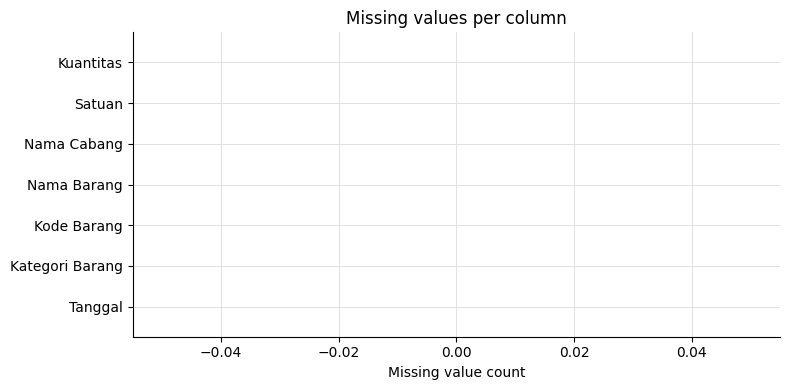

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
display(missing_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_summary.index, missing_summary["missing_count"], color=BLUE)
ax.set_xlabel("Missing value count")
ax.set_title("Missing values per column")
plt.tight_layout()
plt.show()

In [7]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

business_key = ["Tanggal", "Kategori Barang", "Kode Barang", "Nama Barang", "Nama Cabang", "Satuan"]
business_key_dupes = df.duplicated(subset=business_key).sum()
print(f"Business-key duplicate rows (should be 0 post-aggregation): {business_key_dupes}")

Exact duplicate rows: 0
Business-key duplicate rows (should be 0 post-aggregation): 0


In [8]:
categorical_cols = ["Kategori Barang", "Kode Barang", "Nama Barang", "Nama Cabang", "Satuan"]
cardinality = df[categorical_cols].nunique().rename("unique_count")
display(cardinality.to_frame())

,unique_count
Kategori Barang,12
Kode Barang,109
Nama Barang,112
Nama Cabang,67
Satuan,12


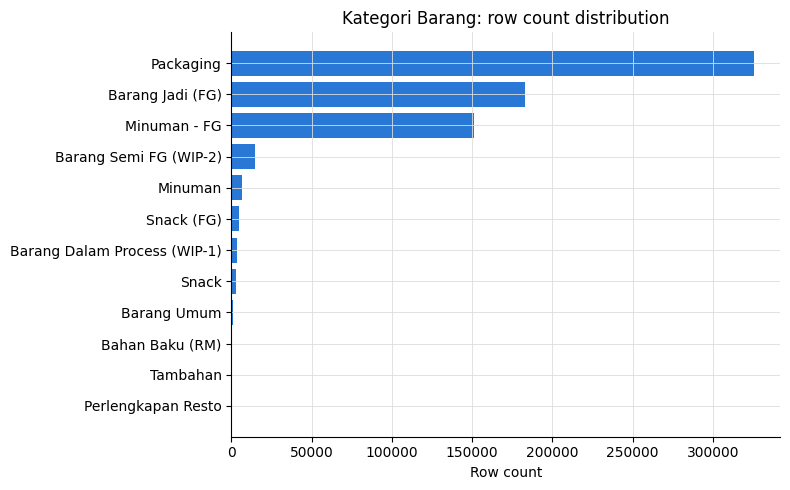

In [9]:
kategori_counts = df["Kategori Barang"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(kategori_counts.index, kategori_counts.values, color=BLUE)
ax.set_xlabel("Row count")
ax.set_title("Kategori Barang: row count distribution")
plt.tight_layout()
plt.show()

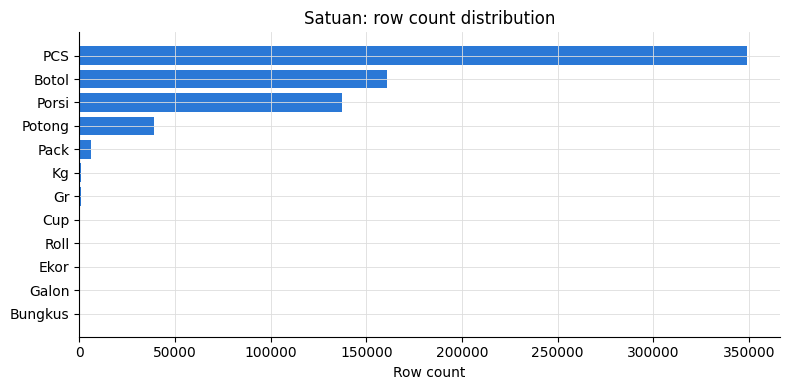

In [10]:
satuan_counts = df["Satuan"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(satuan_counts.index, satuan_counts.values, color=BLUE)
ax.set_xlabel("Row count")
ax.set_title("Satuan: row count distribution")
plt.tight_layout()
plt.show()

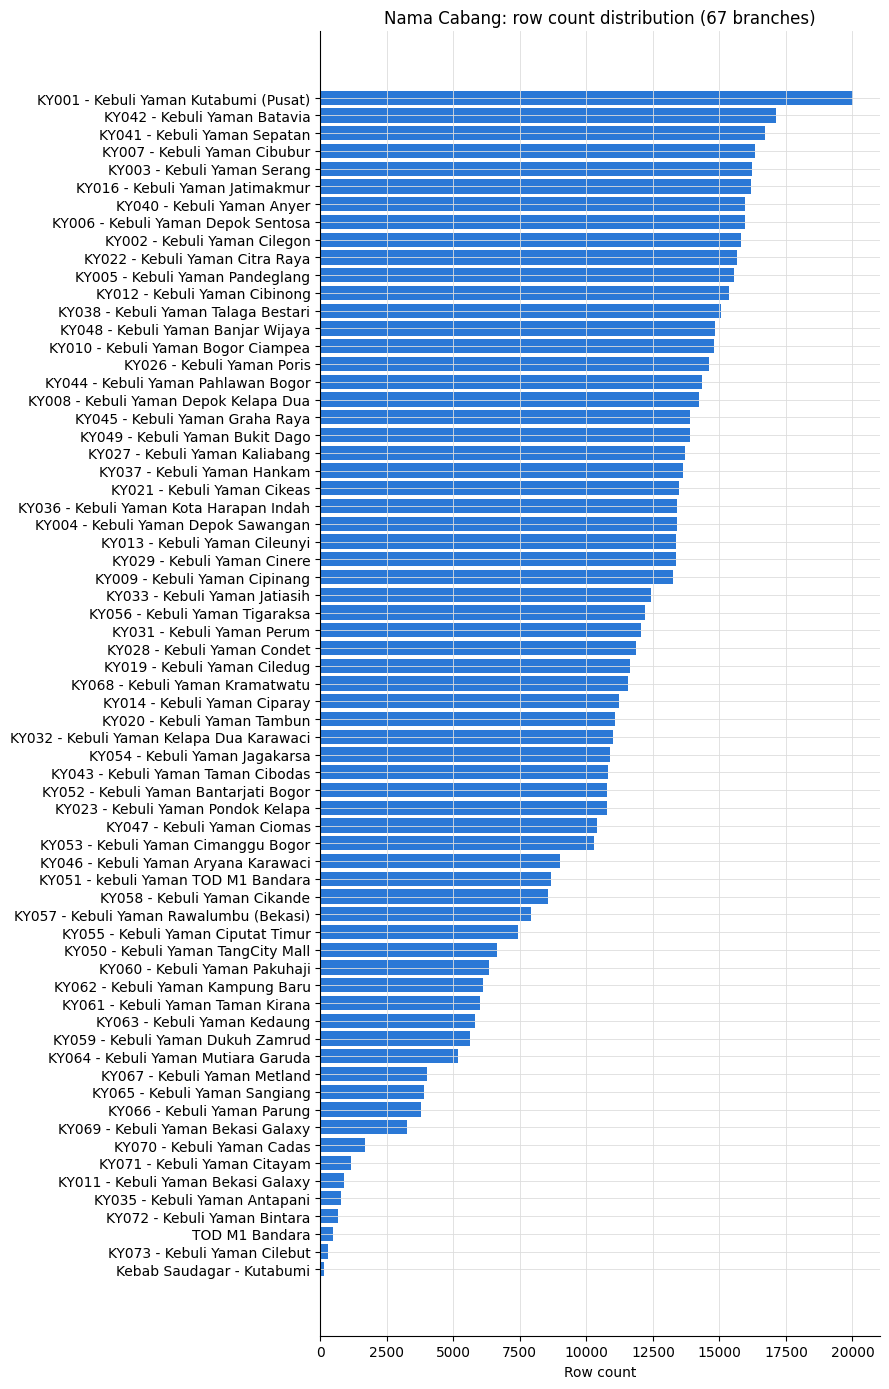

In [11]:
branch_counts = df["Nama Cabang"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 14))
ax.barh(branch_counts.index, branch_counts.values, color=BLUE)
ax.set_xlabel("Row count")
ax.set_title("Nama Cabang: row count distribution (67 branches)")
plt.tight_layout()
plt.show()

In [12]:
top20_by_rows = df["Kode Barang"].value_counts().head(20)
top20_by_volume = (
    df.groupby("Kode Barang")["Kuantitas"].sum().sort_values(ascending=False).head(20)
)

print("Top 20 SKUs by row (transaction) count:")
display(top20_by_rows.to_frame("row_count"))

print("Top 20 SKUs by total Kuantitas (volume):")
display(top20_by_volume.to_frame("total_kuantitas"))

Top 20 SKUs by row (transaction) count:


,row_count
Kode Barang,
FGS-00005,36730
PCG-00010,36730
FGS-00004,36730
FGS-00001,36729
PCG-00001,36598
PCG-00009,35521
FGS-00002,32839
PCG-00011,26495
PCG-00003,26493


Top 20 SKUs by total Kuantitas (volume):


,total_kuantitas
Kode Barang,
FGS-00005,4311074
FGS-00004,4167982
FGS-00001,3233468
PCG-00010,3224822
PCG-00001,2014544
PCG-00009,1029745
PCG-00030,979187
FGS-00002,258890
FGS.00053,200766


## 3. `Kuantitas` Distribution & Outliers

In [13]:
df["Kuantitas"].describe()

count    693563.000000
mean         30.434679
std          61.613872
min           1.000000
25%           2.000000
50%           5.000000
75%          34.000000
max        5250.000000
Name: Kuantitas, dtype: float64

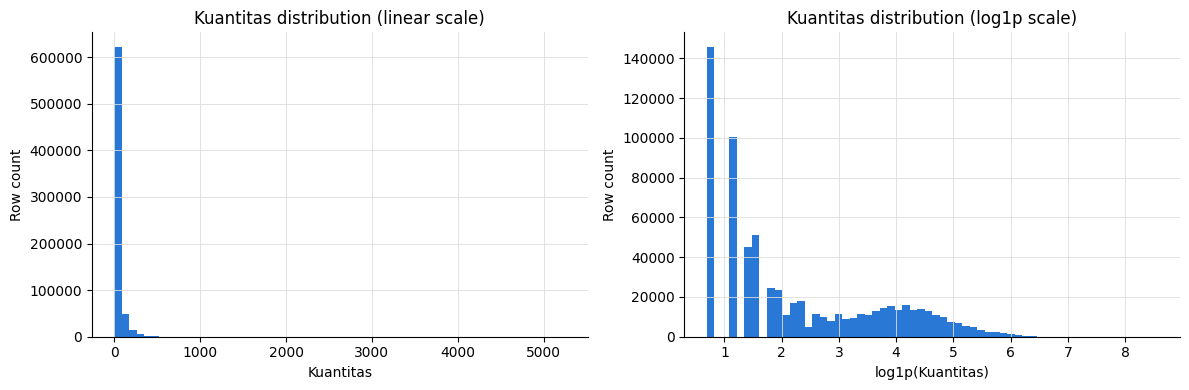

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Kuantitas"], bins=60, color=BLUE)
axes[0].set_title("Kuantitas distribution (linear scale)")
axes[0].set_xlabel("Kuantitas")
axes[0].set_ylabel("Row count")

axes[1].hist(np.log1p(df["Kuantitas"]), bins=60, color=BLUE)
axes[1].set_title("Kuantitas distribution (log1p scale)")
axes[1].set_xlabel("log1p(Kuantitas)")
axes[1].set_ylabel("Row count")

plt.tight_layout()
plt.show()

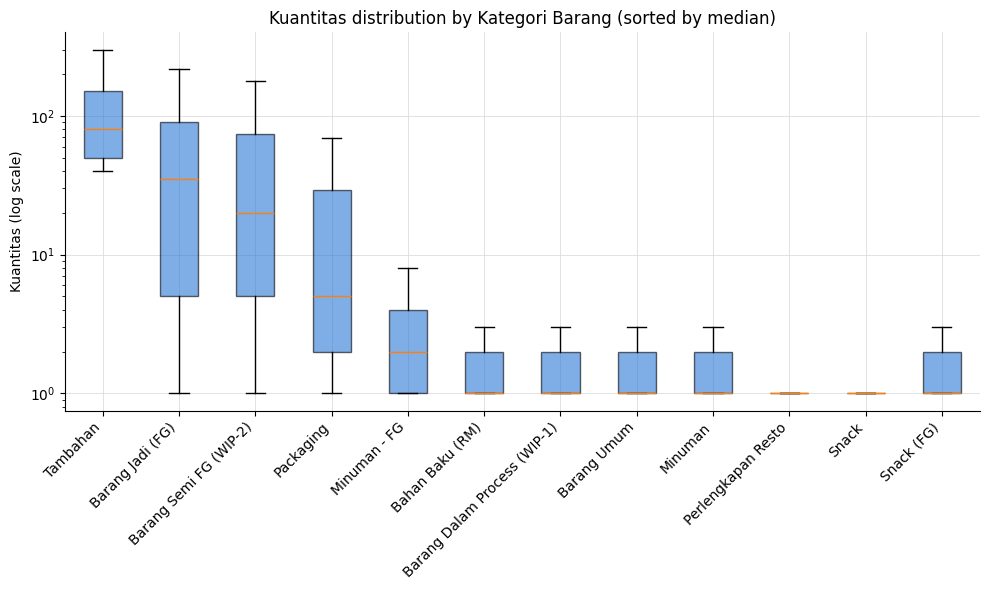

In [15]:
order = (
    df.groupby("Kategori Barang", observed=True)["Kuantitas"]
    .median()
    .sort_values(ascending=False)
    .index
)
data_by_cat = [df.loc[df["Kategori Barang"] == cat, "Kuantitas"] for cat in order]

fig, ax = plt.subplots(figsize=(10, 6))
box = ax.boxplot(data_by_cat, tick_labels=list(order), patch_artist=True, showfliers=False)
for patch in box["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.6)
ax.set_yscale("log")
ax.set_ylabel("Kuantitas (log scale)")
ax.set_title("Kuantitas distribution by Kategori Barang (sorted by median)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
extreme_rows = df.nlargest(20, "Kuantitas")[
    ["Tanggal", "Kode Barang", "Nama Barang", "Nama Cabang", "Kategori Barang", "Kuantitas"]
]
display(extreme_rows)

,Tanggal,Kode Barang,Nama Barang,Nama Cabang,Kategori Barang,Kuantitas
320563,2025-01-25,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),5250
48763,2024-03-08,FGS-00001,Ayam Kebuli (0.9),KY026 - Kebuli Yaman Poris,Barang Jadi (FG),4753
50515,2024-03-10,FGS-00001,Ayam Kebuli (0.9),KY026 - Kebuli Yaman Poris,Barang Jadi (FG),2688
322331,2025-01-27,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),2625
320024,2025-01-25,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),2500
321740,2025-01-26,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY042 - Kebuli Yaman Batavia,Barang Jadi (FG),2250
50674,2024-03-10,FGS-00001,Ayam Kebuli (0.9),KY042 - Kebuli Yaman Batavia,Barang Jadi (FG),2246
44956,2024-03-03,FGS-00001,Ayam Kebuli (0.9),KY026 - Kebuli Yaman Poris,Barang Jadi (FG),2075
321466,2025-01-26,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY001 - Kebuli Yaman Kutabumi (Pusat),Barang Jadi (FG),2000
325166,2025-01-30,xxx.FGS.00069,xxx.Cendol Pandan - FG,KY006 - Kebuli Yaman Depok Sentosa,Barang Jadi (FG),2000


## 4. Temporal Coverage & Continuity

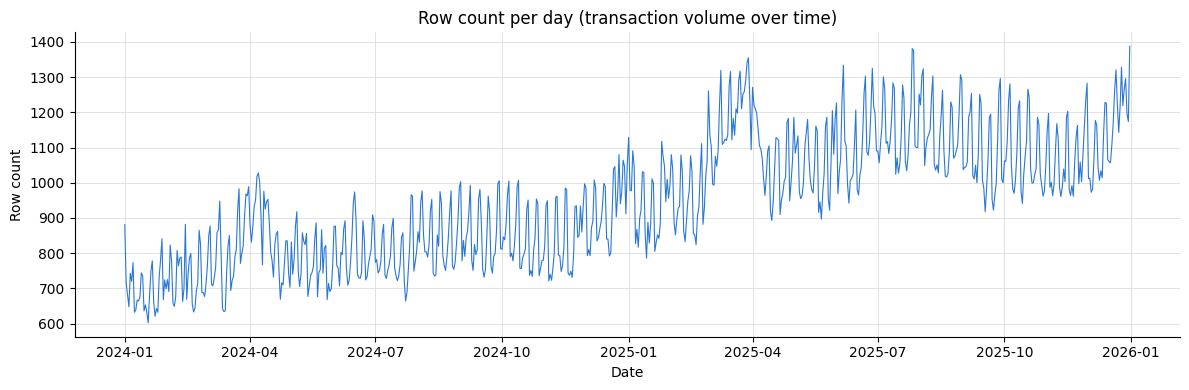

In [17]:
rows_per_day = df.groupby("Tanggal").size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rows_per_day.index, rows_per_day.values, color=BLUE, linewidth=0.8)
ax.set_title("Row count per day (transaction volume over time)")
ax.set_xlabel("Date")
ax.set_ylabel("Row count")
plt.tight_layout()
plt.show()

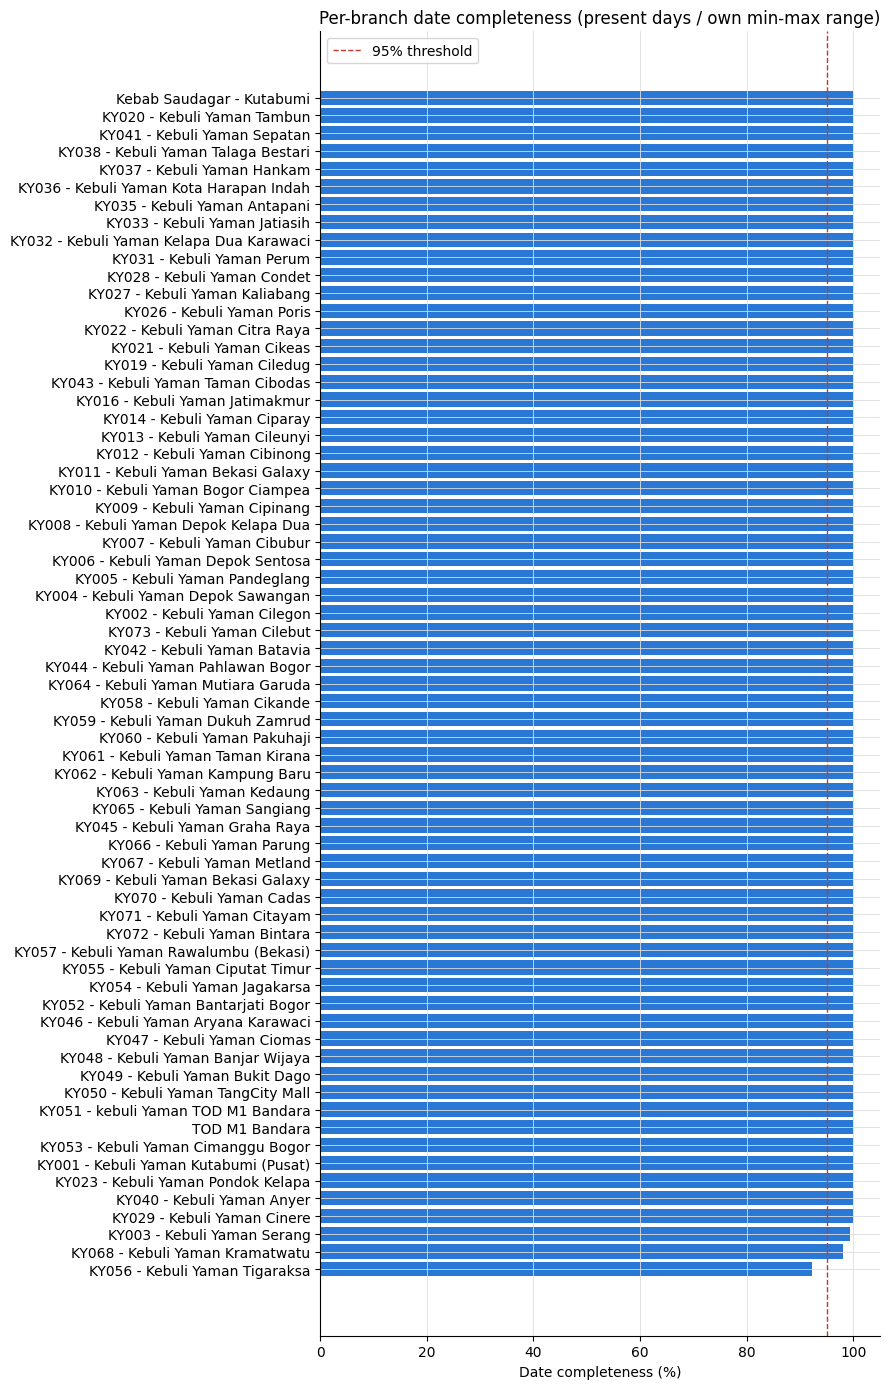

1 branches below 95% completeness:


,min,max,nunique,expected_days,completeness_pct
Nama Cabang,,,,,
KY056 - Kebuli Yaman Tigaraksa,2024-03-01,2025-12-31,619,671,92.250373


In [18]:
branch_ranges = df.groupby("Nama Cabang", observed=True)["Tanggal"].agg(["min", "max", "nunique"])
branch_ranges["expected_days"] = (branch_ranges["max"] - branch_ranges["min"]).dt.days + 1
branch_ranges["completeness_pct"] = branch_ranges["nunique"] / branch_ranges["expected_days"] * 100
branch_ranges = branch_ranges.sort_values("completeness_pct")

fig, ax = plt.subplots(figsize=(9, 14))
ax.barh(branch_ranges.index, branch_ranges["completeness_pct"], color=BLUE)
ax.axvline(95, color="#c0392b", linestyle="--", linewidth=1, label="95% threshold")
ax.set_xlabel("Date completeness (%)")
ax.set_title("Per-branch date completeness (present days / own min-max range)")
ax.legend()
plt.tight_layout()
plt.show()

below_threshold = branch_ranges[branch_ranges["completeness_pct"] < 95]
print(f"{len(below_threshold)} branches below 95% completeness:")
display(below_threshold)

## 5. Time Series & Seasonality

The day-of-week chart below is the one most directly relevant to the Region 1 (Mon/Thu) vs.
Region 2 (Tue/Fri) shipment cadence — but since no branch-to-region mapping exists yet
(see the Open Questions section), it is shown **generically** across all branches/items
combined, not split by region.

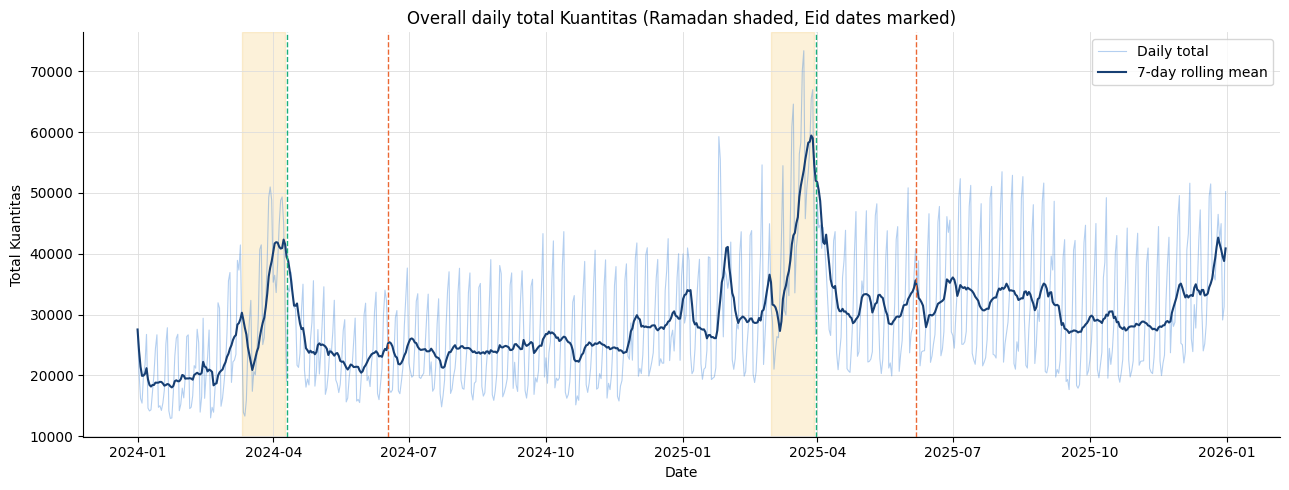

In [19]:
daily_total = df.groupby("Tanggal")["Kuantitas"].sum()
rolling_mean = daily_total.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_total.index, daily_total.values, color=BLUE, alpha=0.35, linewidth=0.8, label="Daily total")
ax.plot(rolling_mean.index, rolling_mean.values, color=BLUE_DARK, linewidth=1.5, label="7-day rolling mean")

for _, (start, end) in calendar_features.RAMADAN_PERIODS.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#eda100", alpha=0.15)

for _, eid_date in calendar_features.EID_AL_FITR_DATES.items():
    ax.axvline(pd.Timestamp(eid_date), color="#1baf7a", linestyle="--", linewidth=1)

for _, eid_date in calendar_features.EID_AL_ADHA_DATES.items():
    ax.axvline(pd.Timestamp(eid_date), color="#eb6834", linestyle="--", linewidth=1)

ax.set_title("Overall daily total Kuantitas (Ramadan shaded, Eid dates marked)")
ax.set_xlabel("Date")
ax.set_ylabel("Total Kuantitas")
ax.legend()
plt.tight_layout()
plt.show()

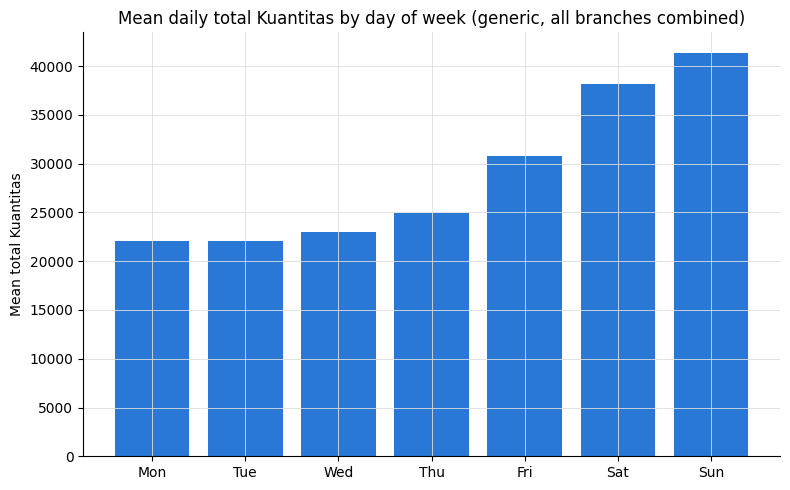

In [20]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df["_dow"] = df["Tanggal"].dt.dayofweek

dow_daily_total = df.groupby(["Tanggal", "_dow"])["Kuantitas"].sum().reset_index()
dow_mean = dow_daily_total.groupby("_dow")["Kuantitas"].mean().reindex(range(7))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(dow_labels, dow_mean.values, color=BLUE)
ax.set_title("Mean daily total Kuantitas by day of week (generic, all branches combined)")
ax.set_ylabel("Mean total Kuantitas")
plt.tight_layout()
plt.show()

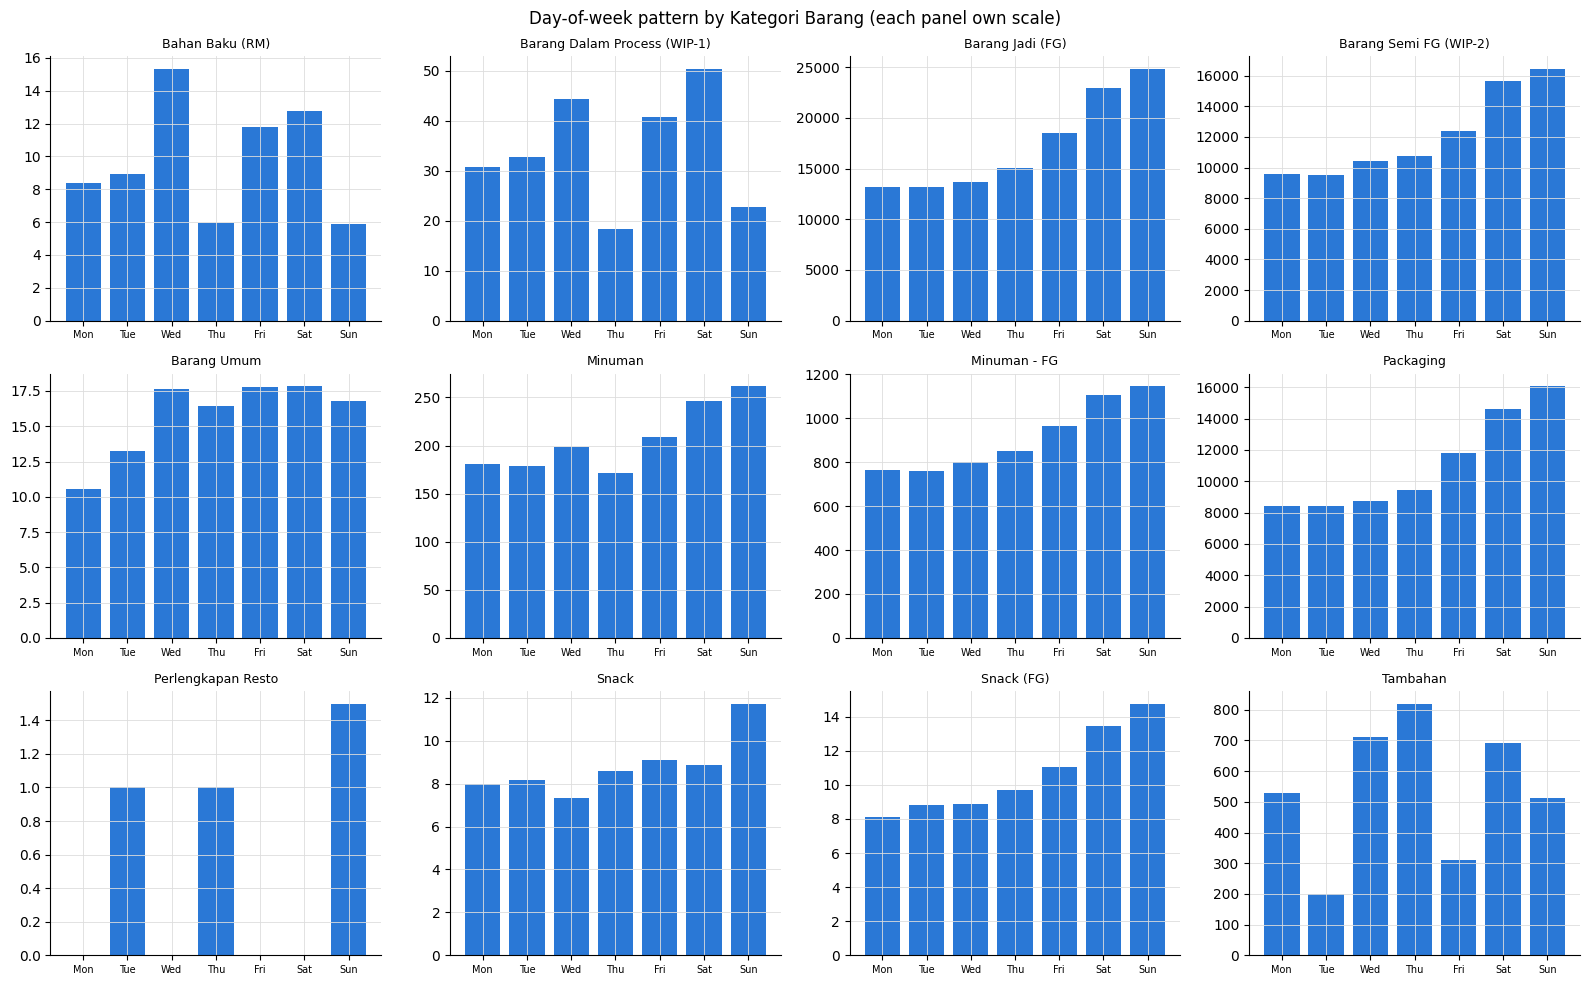

In [21]:
categories = sorted(str(c) for c in df["Kategori Barang"].unique())

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sub = df[df["Kategori Barang"] == cat]
    sub_daily = sub.groupby(["Tanggal", "_dow"])["Kuantitas"].sum().reset_index()
    sub_dow_mean = sub_daily.groupby("_dow")["Kuantitas"].mean().reindex(range(7)).fillna(0)
    axes[i].bar(dow_labels, sub_dow_mean.values, color=BLUE)
    axes[i].set_title(cat, fontsize=9)
    axes[i].tick_params(axis="x", labelsize=7)

for j in range(len(categories), len(axes)):
    axes[j].axis("off")

fig.suptitle("Day-of-week pattern by Kategori Barang (each panel own scale)")
plt.tight_layout()
plt.show()

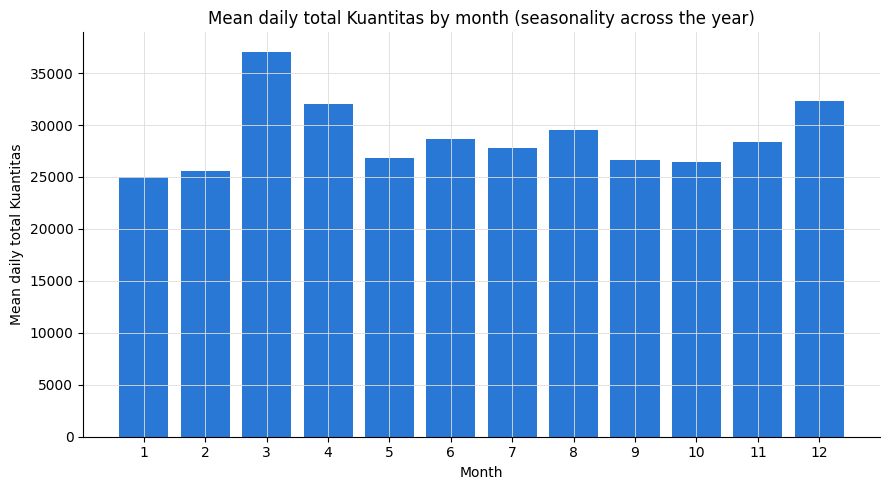

In [22]:
df["_month"] = df["Tanggal"].dt.month
monthly_total = df.groupby(["Tanggal", "_month"])["Kuantitas"].sum().reset_index()
month_mean = monthly_total.groupby("_month")["Kuantitas"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(month_mean.index, month_mean.values, color=BLUE)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily total Kuantitas")
ax.set_title("Mean daily total Kuantitas by month (seasonality across the year)")
plt.tight_layout()
plt.show()

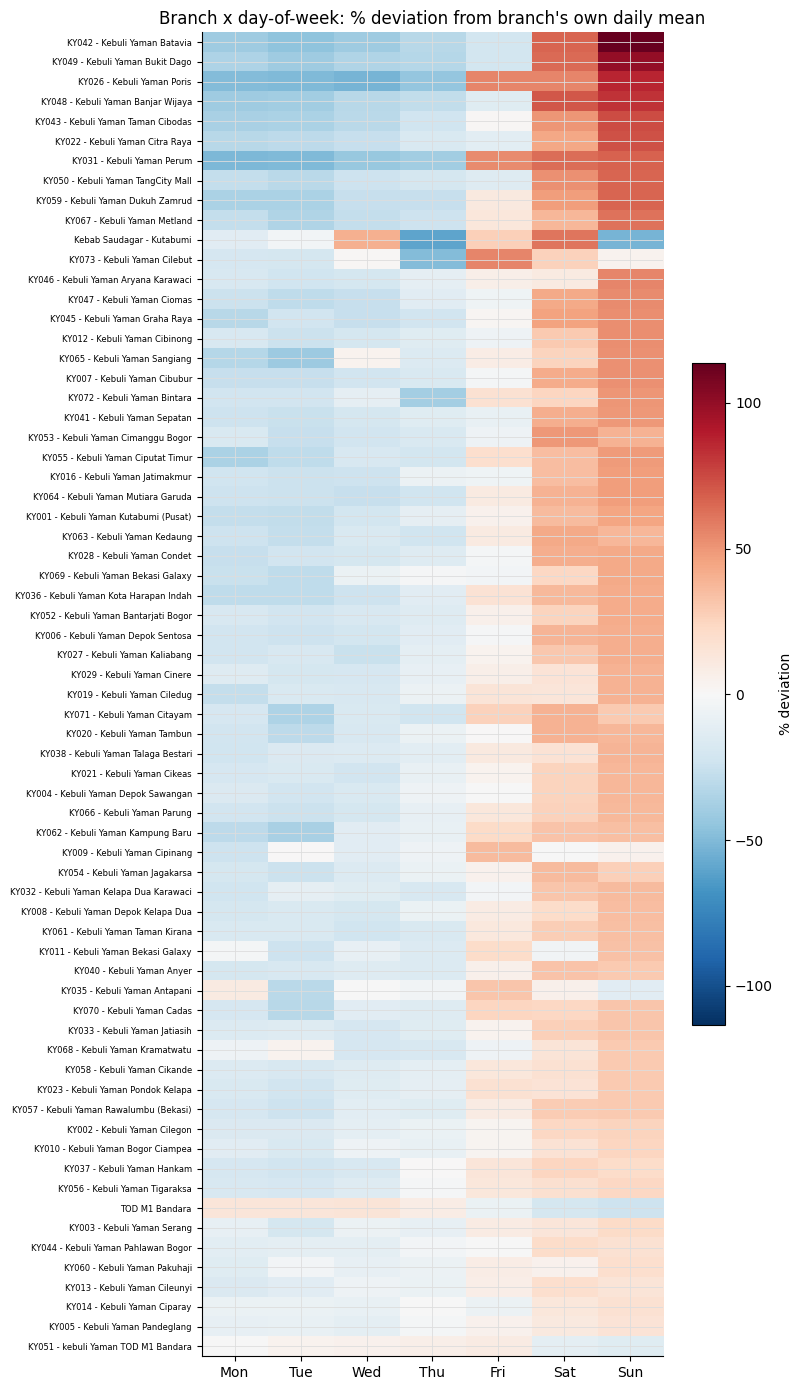

In [23]:
branch_dow = df.groupby(["Nama Cabang", "_dow"], observed=True)["Kuantitas"].sum().reset_index()
branch_dow_pivot = (
    branch_dow.pivot(index="Nama Cabang", columns="_dow", values="Kuantitas")
    .reindex(columns=range(7))
)
branch_mean = branch_dow_pivot.mean(axis=1)
branch_dow_dev = branch_dow_pivot.div(branch_mean, axis=0).sub(1).mul(100)
branch_dow_dev = branch_dow_dev.loc[branch_dow_dev.abs().max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 14))
vmax = branch_dow_dev.abs().to_numpy().max()
im = ax.imshow(branch_dow_dev.values, aspect="auto", cmap=DIVERGING_CMAP, vmin=-vmax, vmax=vmax)
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_yticks(range(len(branch_dow_dev)))
ax.set_yticklabels(branch_dow_dev.index, fontsize=6)
ax.set_title("Branch x day-of-week: % deviation from branch's own daily mean")
fig.colorbar(im, ax=ax, label="% deviation", shrink=0.5)
plt.tight_layout()
plt.show()

## 6. Item x Outlet Structure

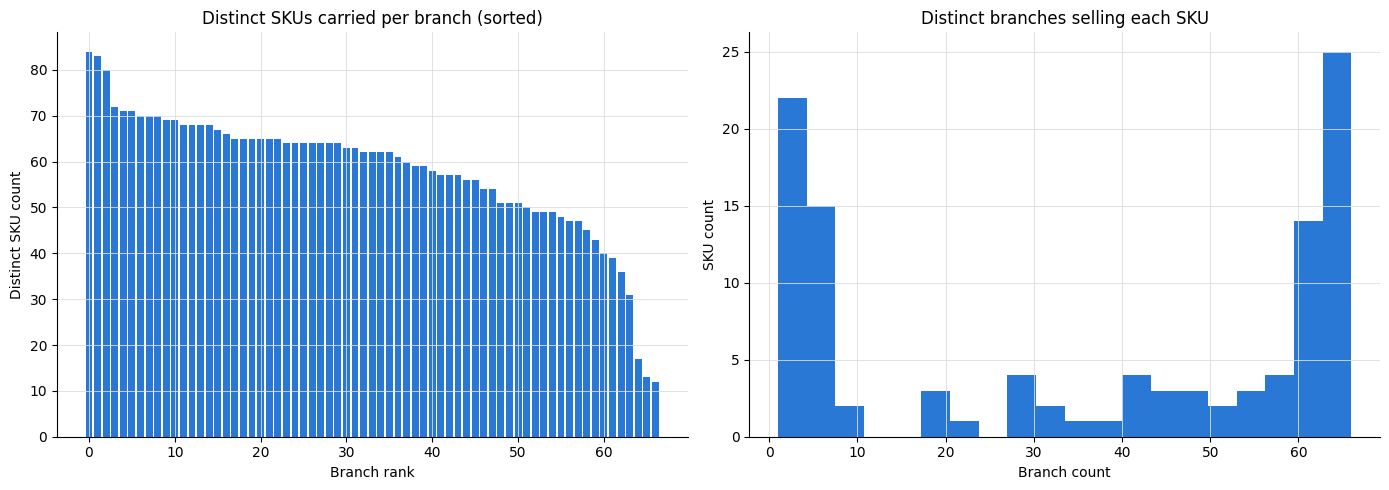

In [24]:
sku_per_branch = df.groupby("Nama Cabang", observed=True)["Kode Barang"].nunique().sort_values(ascending=False)
branch_per_sku = df.groupby("Kode Barang")["Nama Cabang"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(len(sku_per_branch)), sku_per_branch.values, color=BLUE)
axes[0].set_title("Distinct SKUs carried per branch (sorted)")
axes[0].set_xlabel("Branch rank")
axes[0].set_ylabel("Distinct SKU count")

axes[1].hist(branch_per_sku.values, bins=20, color=BLUE)
axes[1].set_title("Distinct branches selling each SKU")
axes[1].set_xlabel("Branch count")
axes[1].set_ylabel("SKU count")

plt.tight_layout()
plt.show()

/Users/ramapdp/Project/Personal/forecast-scm/build_panel.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for keys, group in df.groupby(pair_cols):


Dense panel shape: (1516114, 6)


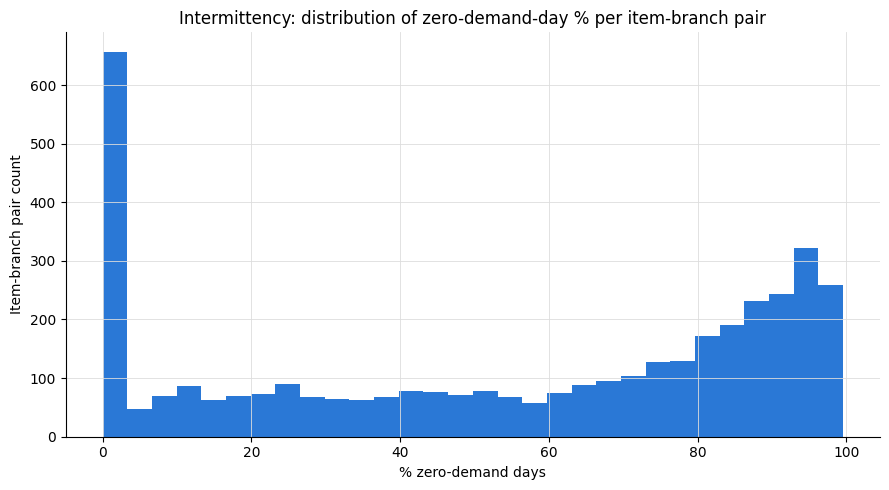

Median zero-demand %: 64.0%
Share of pairs with >50% zero-demand days: 57.1%


In [25]:
panel = build_panel.build_dense_panel(df)
print(f"Dense panel shape: {panel.shape}")

zero_pct = (
    panel.assign(is_zero=panel["Kuantitas"] == 0)
    .groupby(["Kode Barang", "Nama Cabang"], observed=True)["is_zero"]
    .mean()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(zero_pct.values, bins=30, color=BLUE)
ax.set_xlabel("% zero-demand days")
ax.set_ylabel("Item-branch pair count")
ax.set_title("Intermittency: distribution of zero-demand-day % per item-branch pair")
plt.tight_layout()
plt.show()

print(f"Median zero-demand %: {zero_pct.median():.1f}%")
print(f"Share of pairs with >50% zero-demand days: {(zero_pct > 50).mean() * 100:.1f}%")

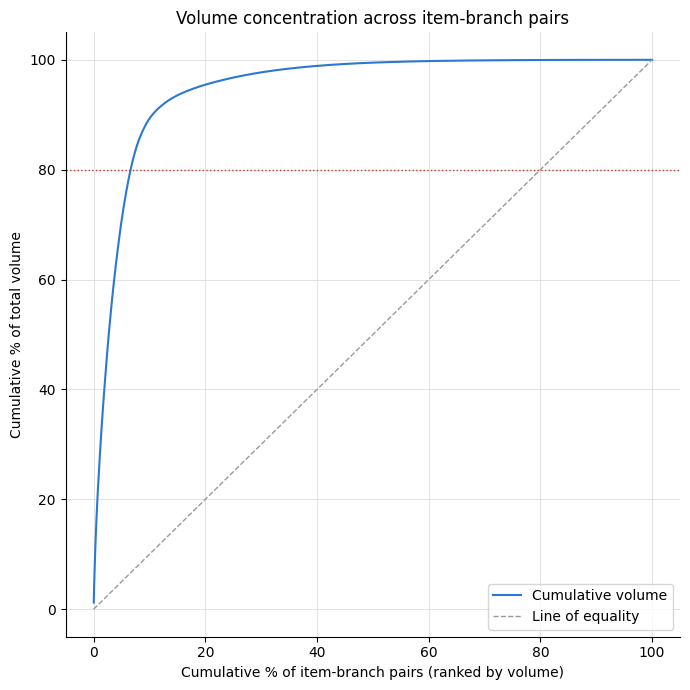

Top 6.6% of item-branch pairs account for 80% of total volume


In [26]:
pair_volume = (
    df.groupby(["Kode Barang", "Nama Cabang"], observed=True)["Kuantitas"]
    .sum()
    .sort_values(ascending=False)
)
cum_volume_pct = (pair_volume.cumsum() / pair_volume.sum() * 100).values
cum_pairs_pct = np.arange(1, len(pair_volume) + 1) / len(pair_volume) * 100

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(cum_pairs_pct, cum_volume_pct, color=BLUE, linewidth=1.5, label="Cumulative volume")
ax.plot([0, 100], [0, 100], color="#999999", linestyle="--", linewidth=1, label="Line of equality")
ax.axhline(80, color="#c0392b", linestyle=":", linewidth=1)
ax.set_xlabel("Cumulative % of item-branch pairs (ranked by volume)")
ax.set_ylabel("Cumulative % of total volume")
ax.set_title("Volume concentration across item-branch pairs")
ax.legend()
plt.tight_layout()
plt.show()

idx_80 = int(np.searchsorted(cum_volume_pct, 80))
print(f"Top {cum_pairs_pct[idx_80]:.1f}% of item-branch pairs account for 80% of total volume")

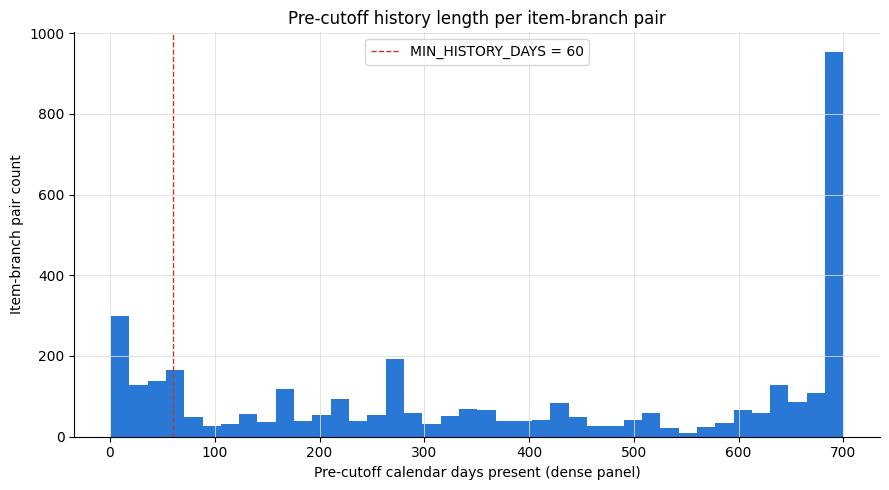

3040/3882 pairs (78.3%) meet the 60-day minimum-history threshold used downstream (build_panel.filter_min_history)


In [27]:
filtered = build_panel.filter_min_history(panel)
n_total_pairs = panel[["Kode Barang", "Nama Cabang"]].drop_duplicates().shape[0]
n_passing_pairs = filtered[["Kode Barang", "Nama Cabang"]].drop_duplicates().shape[0]

pre_cutoff_panel = panel[panel["Tanggal"] < build_panel.TEST_START]
history_days = pre_cutoff_panel.groupby(["Kode Barang", "Nama Cabang"], observed=True).size()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(history_days.values, bins=40, color=BLUE)
ax.axvline(
    build_panel.MIN_HISTORY_DAYS, color="#c0392b", linestyle="--", linewidth=1,
    label=f"MIN_HISTORY_DAYS = {build_panel.MIN_HISTORY_DAYS}",
)
ax.set_xlabel("Pre-cutoff calendar days present (dense panel)")
ax.set_ylabel("Item-branch pair count")
ax.set_title("Pre-cutoff history length per item-branch pair")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"{n_passing_pairs}/{n_total_pairs} pairs ({n_passing_pairs / n_total_pairs * 100:.1f}%) "
    f"meet the {build_panel.MIN_HISTORY_DAYS}-day minimum-history threshold used downstream "
    "(build_panel.filter_min_history)"
)

## 7. Lead-Time Proxy Analysis

Generic (non-region-segmented) rolling 3-day and 4-day trailing cumulative-demand windows,
as a proxy for "demand until next shipment" under the Region 1 (3- or 4-day gap depending on
Mon vs. Thu shipment) / Region 2 (3- or 4-day gap depending on Tue vs. Fri shipment) cadence.
**These windows are deliberately not anchored to any guessed region/day assignment** — that
would require the Region 1/2 mapping this notebook explicitly does not have (see Open
Questions).

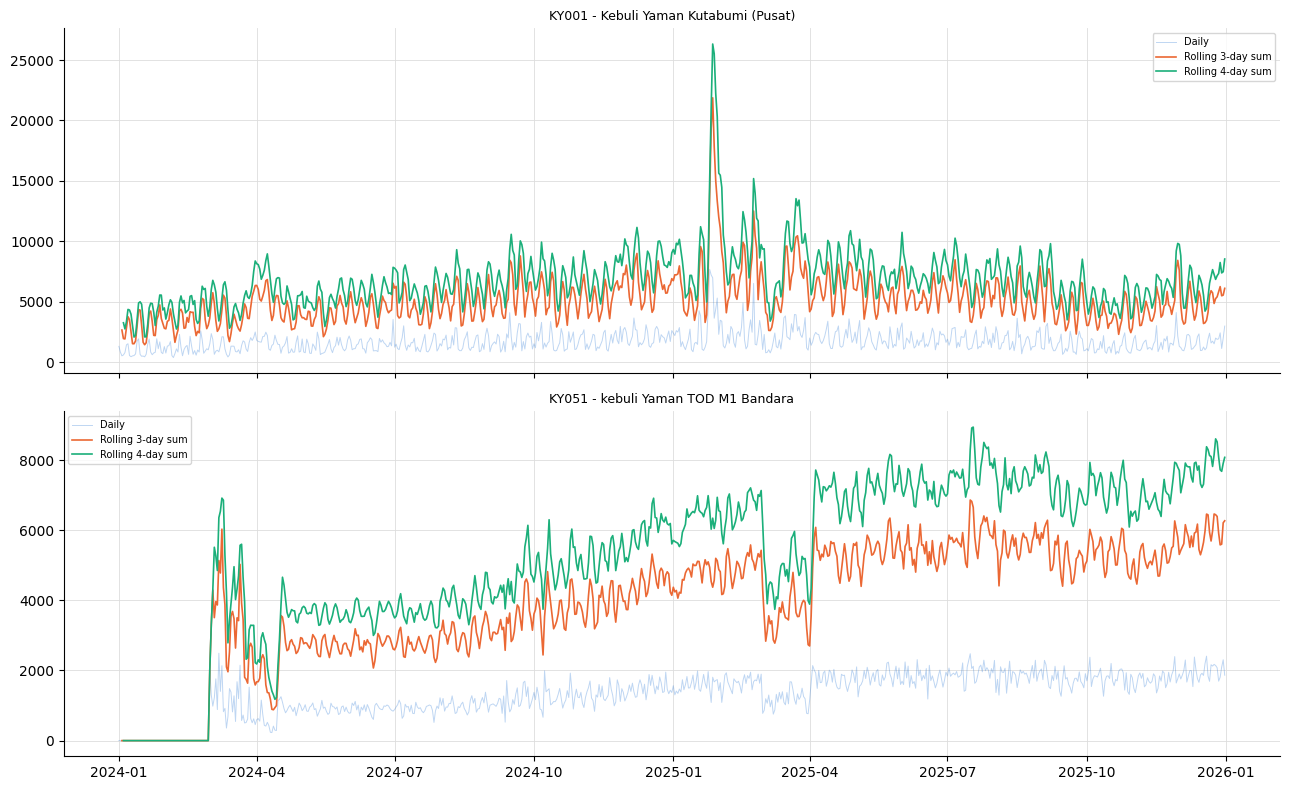

In [28]:
full_range = pd.date_range(df["Tanggal"].min(), df["Tanggal"].max(), freq="D")
branch_daily_pivot = (
    df.pivot_table(index="Tanggal", columns="Nama Cabang", values="Kuantitas", aggfunc="sum", observed=True)
    .reindex(full_range)
    .fillna(0)
)

roll_3 = branch_daily_pivot.rolling(3).sum()
roll_4 = branch_daily_pivot.rolling(4).sum()

top2_branches = (
    df.groupby("Nama Cabang", observed=True)["Kuantitas"].sum().sort_values(ascending=False).head(2).index.tolist()
)

fig, axes = plt.subplots(len(top2_branches), 1, figsize=(13, 8), sharex=True)
for ax, branch in zip(axes, top2_branches):
    ax.plot(branch_daily_pivot.index, branch_daily_pivot[branch], color=BLUE, alpha=0.3, linewidth=0.7, label="Daily")
    ax.plot(roll_3.index, roll_3[branch], color=CATEGORICAL[1], linewidth=1.2, label="Rolling 3-day sum")
    ax.plot(roll_4.index, roll_4[branch], color=CATEGORICAL[2], linewidth=1.2, label="Rolling 4-day sum")
    ax.set_title(branch, fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

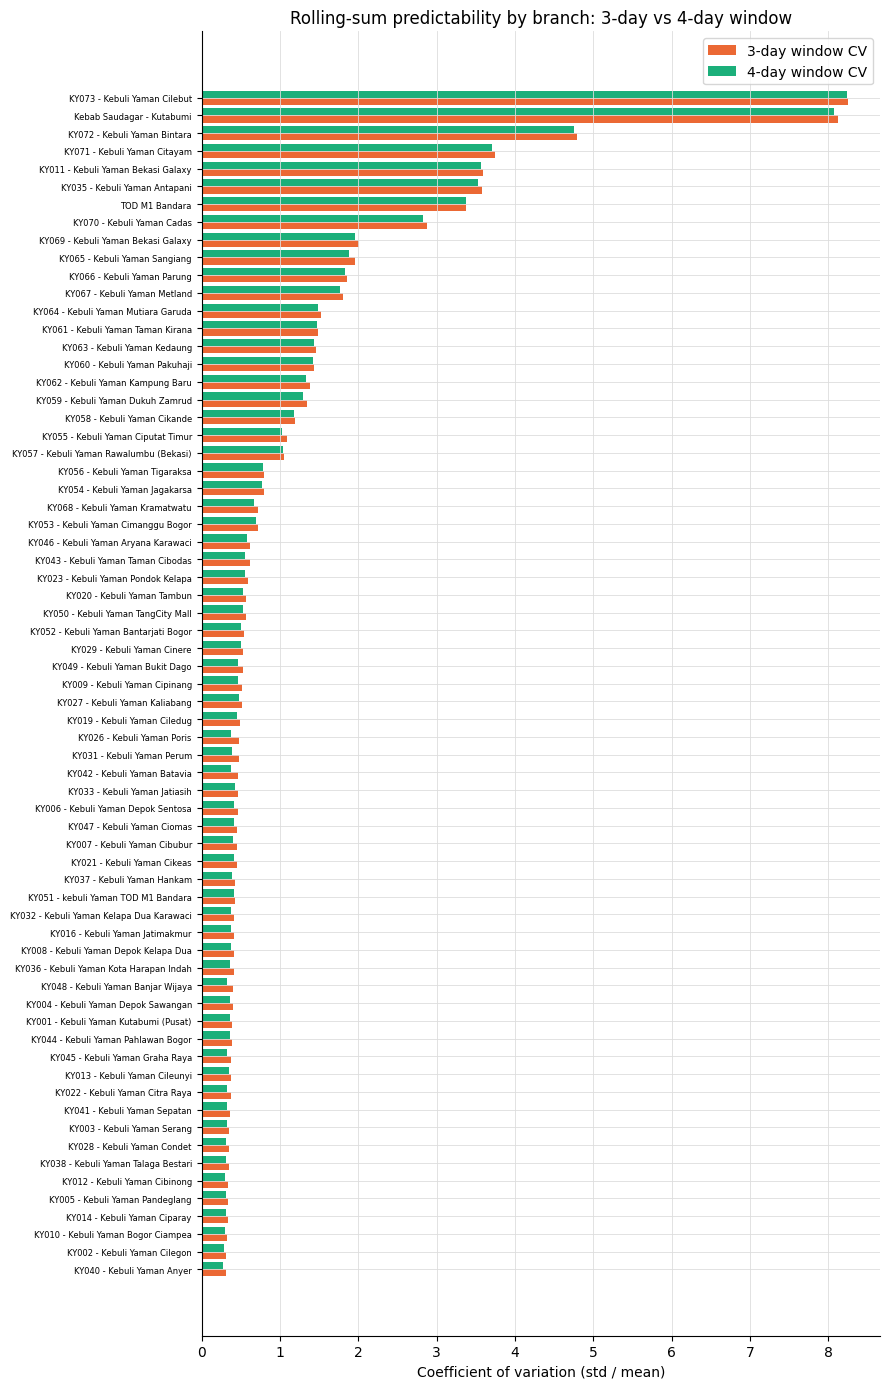

In [29]:
cv_3 = roll_3.std() / roll_3.mean()
cv_4 = roll_4.std() / roll_4.mean()
cv_compare = pd.DataFrame({"cv_3day": cv_3, "cv_4day": cv_4}).sort_values("cv_3day")

fig, ax = plt.subplots(figsize=(9, 14))
y = np.arange(len(cv_compare))
ax.barh(y - 0.2, cv_compare["cv_3day"], height=0.4, color=CATEGORICAL[1], label="3-day window CV")
ax.barh(y + 0.2, cv_compare["cv_4day"], height=0.4, color=CATEGORICAL[2], label="4-day window CV")
ax.set_yticks(y)
ax.set_yticklabels(cv_compare.index, fontsize=6)
ax.set_xlabel("Coefficient of variation (std / mean)")
ax.set_title("Rolling-sum predictability by branch: 3-day vs 4-day window")
ax.legend()
plt.tight_layout()
plt.show()

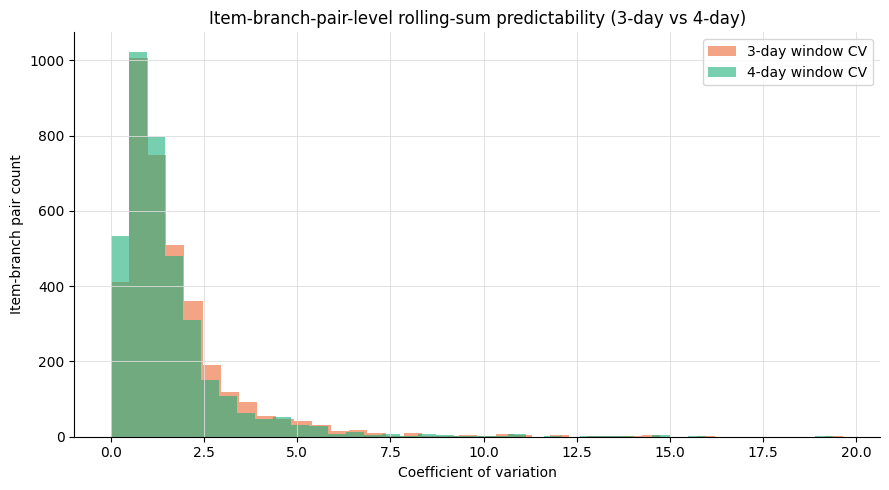

,cv_3,cv_4
count,3707.000000,3696.000000
mean,1.729646,1.559883
std,1.682540,1.593513
min,0.000000,0.000000
25%,0.756639,0.676965
50%,1.251207,1.118254
75%,2.086658,1.849979
max,19.658069,19.371721


In [30]:
panel_sorted = panel.sort_values(["Kode Barang", "Nama Cabang", "Tanggal"])
grp = panel_sorted.groupby(["Kode Barang", "Nama Cabang"], observed=True)["Kuantitas"]
panel_sorted["roll_3"] = grp.transform(lambda s: s.rolling(3).sum())
panel_sorted["roll_4"] = grp.transform(lambda s: s.rolling(4).sum())

pair_cv = panel_sorted.groupby(["Kode Barang", "Nama Cabang"], observed=True).agg(
    cv_3=("roll_3", lambda s: s.std() / s.mean() if s.mean() else np.nan),
    cv_4=("roll_4", lambda s: s.std() / s.mean() if s.mean() else np.nan),
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(pair_cv["cv_3"].dropna(), bins=40, alpha=0.6, color=CATEGORICAL[1], label="3-day window CV")
ax.hist(pair_cv["cv_4"].dropna(), bins=40, alpha=0.6, color=CATEGORICAL[2], label="4-day window CV")
ax.set_xlabel("Coefficient of variation")
ax.set_ylabel("Item-branch pair count")
ax.set_title("Item-branch-pair-level rolling-sum predictability (3-day vs 4-day)")
ax.legend()
plt.tight_layout()
plt.show()

pair_cv.describe()

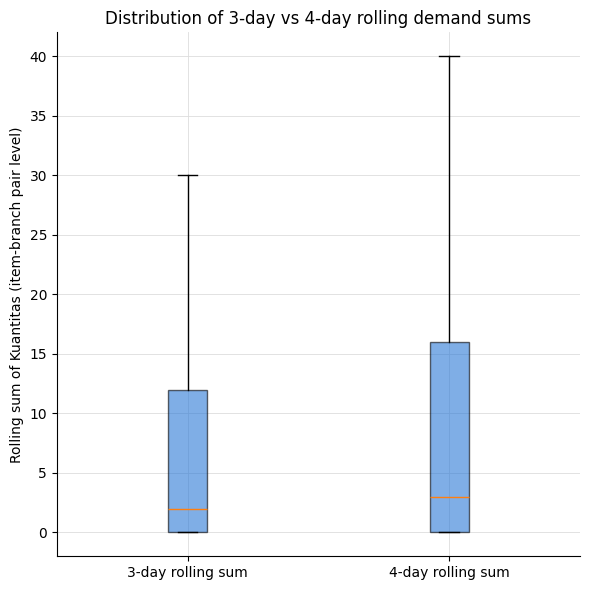

In [31]:
fig, ax = plt.subplots(figsize=(6, 6))
box = ax.boxplot(
    [panel_sorted["roll_3"].dropna(), panel_sorted["roll_4"].dropna()],
    tick_labels=["3-day rolling sum", "4-day rolling sum"],
    patch_artist=True,
    showfliers=False,
)
for patch in box["boxes"]:
    patch.set_facecolor(BLUE)
    patch.set_alpha(0.6)
ax.set_ylabel("Rolling sum of Kuantitas (item-branch pair level)")
ax.set_title("Distribution of 3-day vs 4-day rolling demand sums")
plt.tight_layout()
plt.show()

## 8. Open Questions / Data Gaps

In [32]:
outlets_df = outlet_features.load_outlets()
print("dataset/outlets.csv columns:")
print(list(outlets_df.columns))

negative_count = int((df["Kuantitas"] < 0).sum())
if negative_count == 0:
    print("OK: no negative Kuantitas values found in dataset.csv (soft check, not an assertion).")
else:
    print(
        f"NOTE: found {negative_count} negative Kuantitas rows — see CLAUDE.md for the known "
        "KY011 2024-02-29 anomaly context."
    )

dataset/outlets.csv columns:
['Nama Outlet', 'Alamat', 'Kecamatan', 'Kota', 'has_shopee', 'has_gofood', 'has_grabfood']
OK: no negative Kuantitas values found in dataset.csv (soft check, not an assertion).


**Findings and open items for a human/data-owner decision:**

1. **Region 1 / Region 2 mapping is missing.** `dataset/outlets.csv` has no region or
   delivery-schedule column (only `Kecamatan`/`Kota`). This blocks any per-region
   segmentation of the day-of-week (§5) and lead-time-window (§7) analyses above,
   which are therefore generic proxies only. **Unblocking ask:** the SCM team supplies a
   branch &rarr; region (or branch &rarr; delivery-day) mapping, ideally as a new column on
   `dataset/outlets.csv`, joined the same way `outlet_features.py` already joins
   `has_shopee`/`has_gofood`/`has_grabfood`.
2. Branches flagged below the 95% date-completeness threshold (§4) and item-branch pairs
   failing the `MIN_HISTORY_DAYS` (60-day) threshold (§6) are worth a data-owner sanity
   check before they're excluded downstream — is missing data a reporting gap, a genuinely
   closed/paused outlet, or a new item?
3. The top-`Kuantitas` outlier rows in §3 are worth a quick eyeball for data-entry errors
   (e.g. a wrong unit multiplier) vs. genuine bulk orders.
4. The negative-`Kuantitas` soft check above is consistent with the existing note in
   `CLAUDE.md` about the KY011 2024-02-29 anomaly (already resolved in this dataset as of
   this run) — no negative values were expected or found.